In [ ]:
#| include: false

# /// script
# requires-python = ">=3.10"
# dependencies = [
#   "matplotlib",
#   "numpy",
#   "pandas",
#   "pymc",
#   "scipy",
#   "seaborn",
# ]
# ///


In [2]:
%matplotlib inline
import numpy as np
import scipy as sp
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.width', 500)
pd.set_option('display.max_columns', 100)
pd.set_option('display.notebook_repr_html', True)
import seaborn as sns
sns.set_style('whitegrid')
sns.set_context('poster')
import pymc as pm
import pytensor.tensor as pt
import arviz as az

Here is a close set of 2 gaussians.

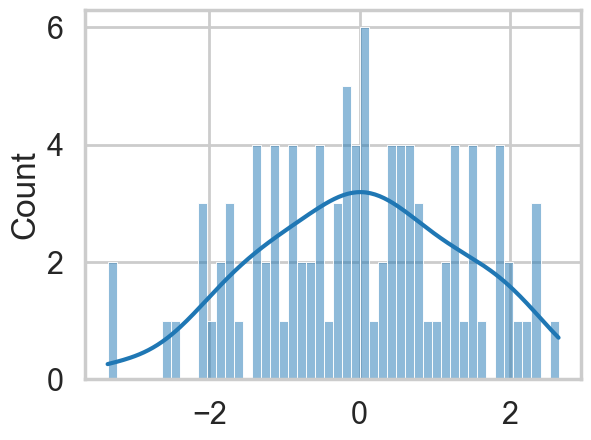

In [3]:
mu_true = np.array([-1, 1])
sigma_true = np.array([1, 1])
lambda_true = np.array([1/2, 1/2])
n = 100
from scipy.stats import multinomial
# Simulate from each distribution according to mixing proportion psi
z = multinomial.rvs(1, lambda_true, size=n)
data=np.array([np.random.normal(mu_true[i.astype('bool')][0], sigma_true[i.astype('bool')][0]) for i in z])
sns.histplot(data, bins=50, kde=True);

We sample, without imposing any ordering.

In [4]:
with pm.Model() as model1:
    p = [1/2, 1/2]
    means = pm.Normal('means', mu=0, sigma=10, shape=2)
    points = pm.NormalMixture('obs', p, mu=means, sigma=1, observed=data)


In [5]:
with model1:
    trace1 = pm.sample(10000, tune=2000, target_accept=0.95)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [means]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 10_000 draw iterations (8_000 + 40_000 draws total) took 4 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


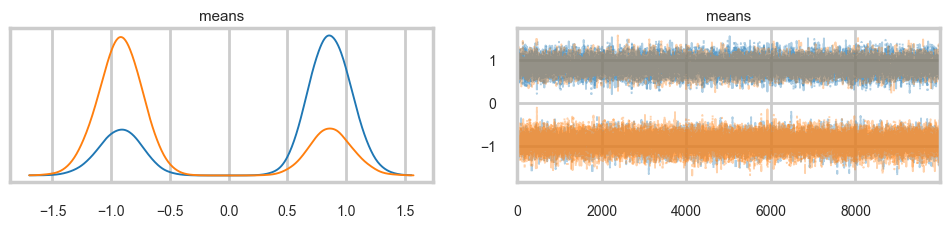

In [6]:
az.plot_trace(trace1, combined=True);

...and land up in a situation where we get mode-switching in one chain

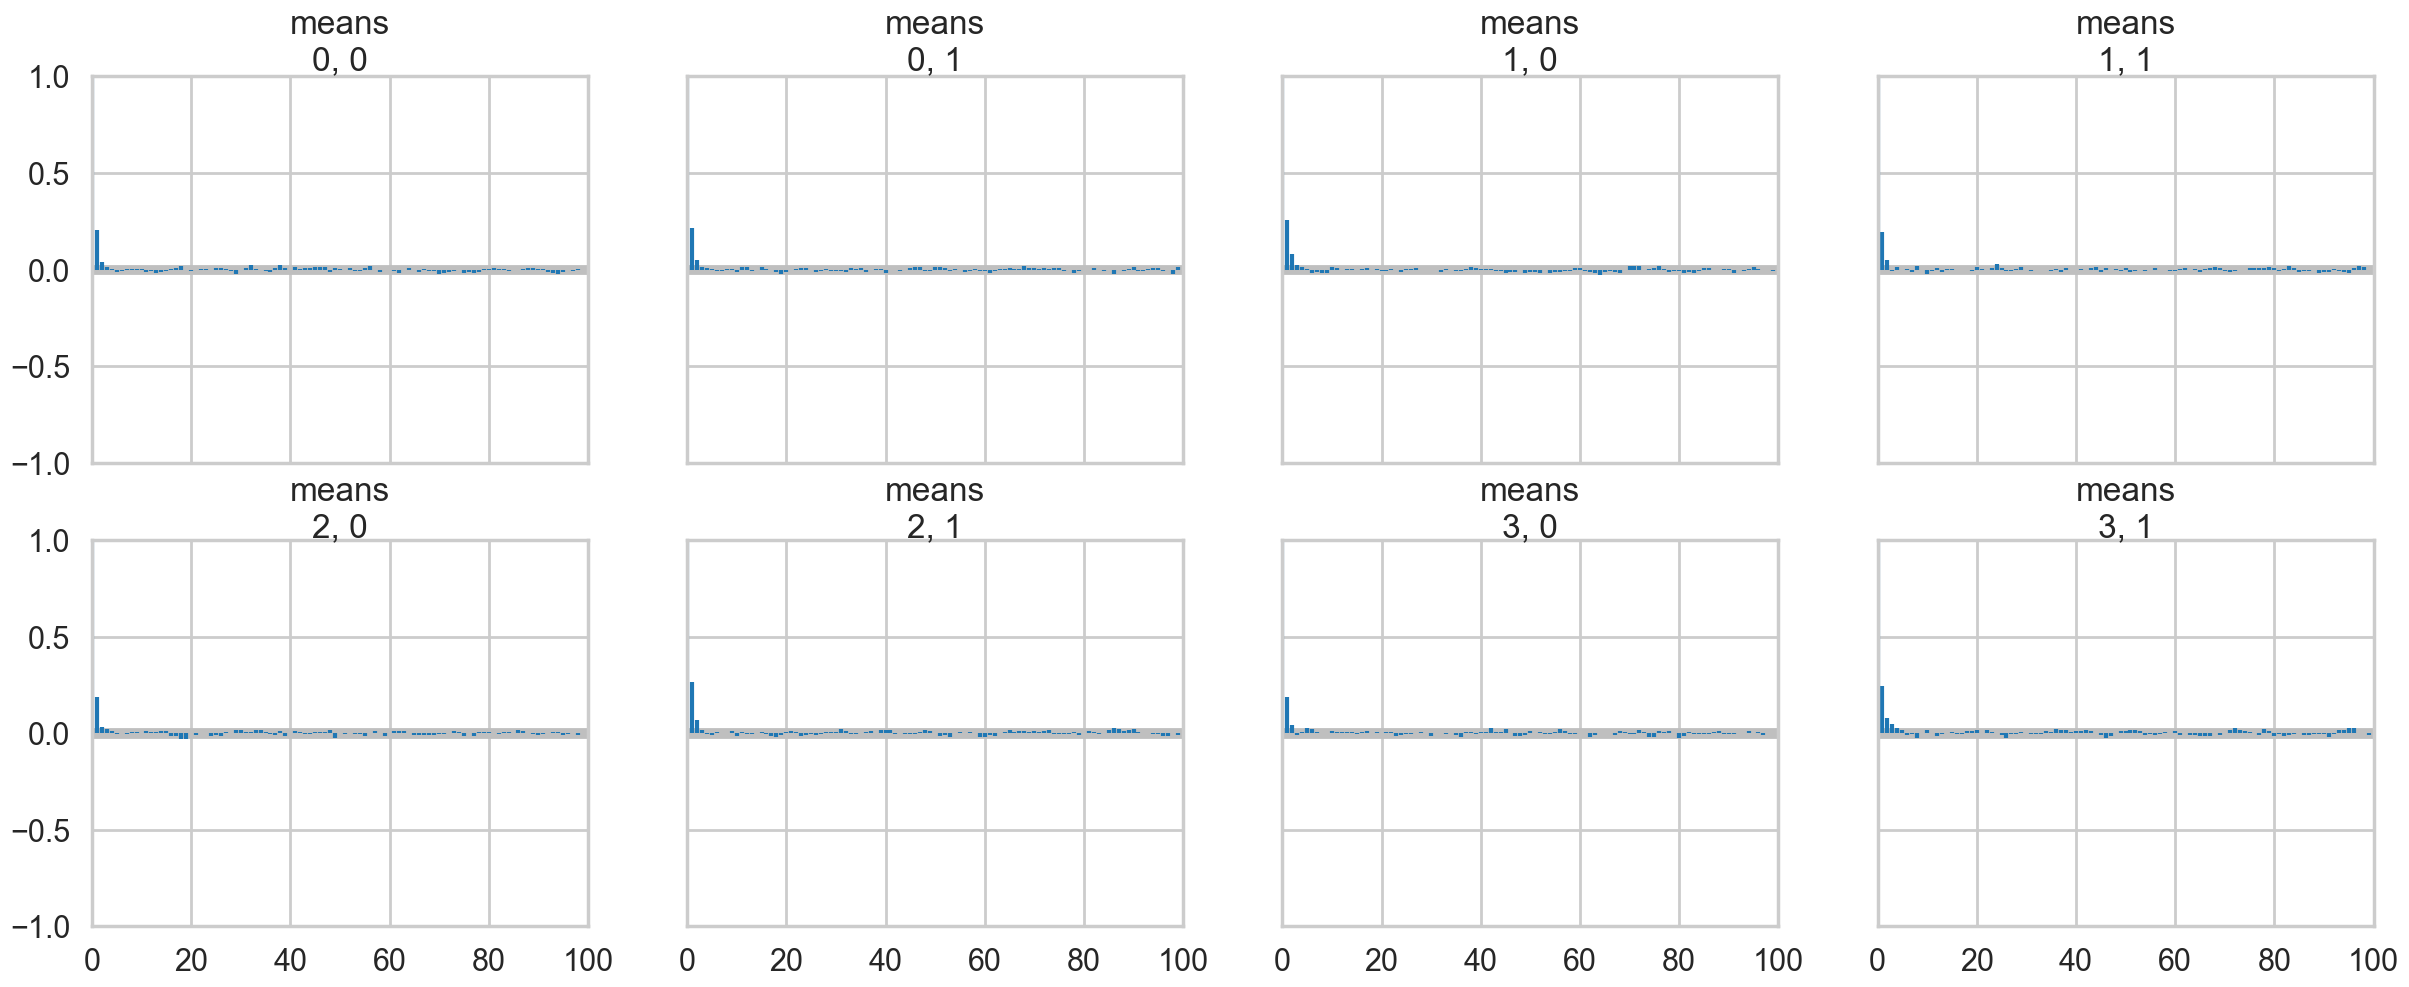

In [7]:
az.plot_autocorr(trace1);

In [8]:
mtrace1 = trace1.posterior['means'].values.reshape(-1, 2)[::2]
mtrace1.shape

(20000, 2)

In [9]:
np.logspace(-10,2,13)

array([1.e-10, 1.e-09, 1.e-08, 1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03,
       1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02])

As a result, the 2D posterior becomes multimodal..our sampler is having identifiability problems which show up in the ridiculously bad autocorrelation.

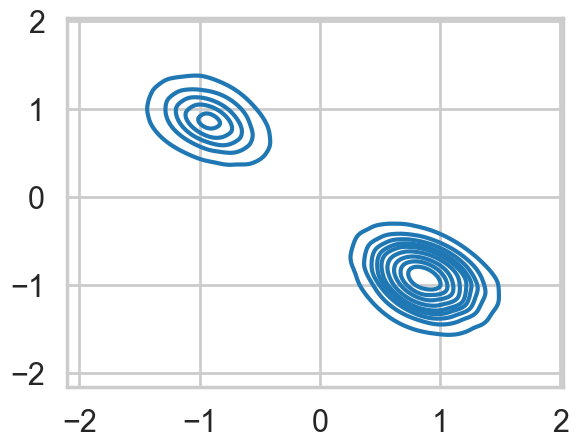

In [10]:
sns.kdeplot(x=mtrace1[:,0], y=mtrace1[:,1]);

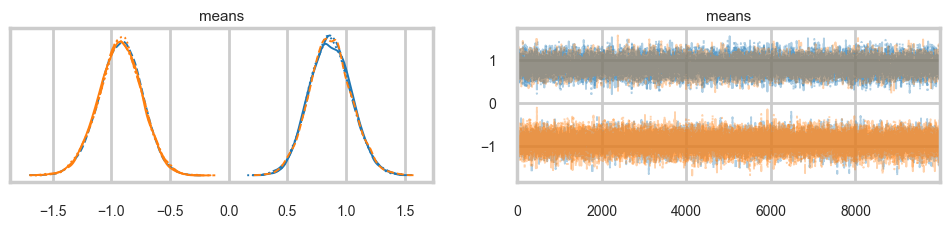

In [11]:
az.plot_trace(trace1);

We fix this by adding an ordering transform

In [12]:
with pm.Model() as model2:
    p = [1/2, 1/2]

    means = pm.Normal('means', mu=0, sigma=10, shape=2,
                  transform=pm.distributions.transforms.ordered,
                  initval=np.array([-1, 1]))
    points = pm.NormalMixture('obs', p, mu=means, sigma=1, observed=data)

In [13]:
with model2:
    trace2 = pm.sample(10000, tune=2000, target_accept=0.95)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [means]


/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 10_000 draw iterations (8_000 + 40_000 draws total) took 6 seconds.


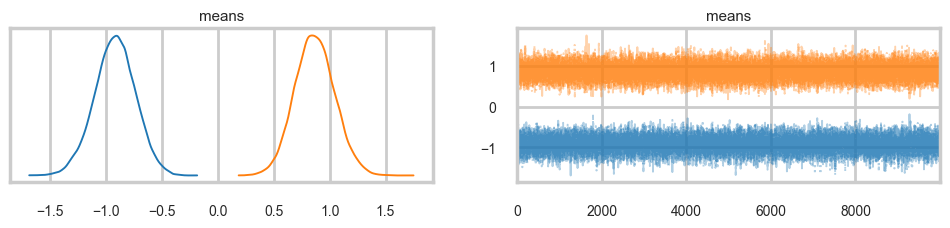

In [14]:
az.plot_trace(trace2, combined=True);

...and the multi-modality goes away...

In [15]:
mtrace2 = trace2.posterior['means'].values.reshape(-1, 2)[::2]
mtrace2.shape

(20000, 2)

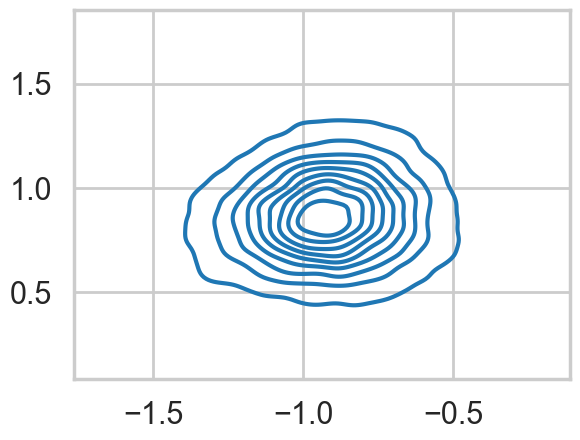

In [16]:
sns.kdeplot(x=mtrace2[:,0], y=mtrace2[:,1]);

## ADVI

In [17]:
with model1:
    approx1 = pm.fit(n=15000, method="advi")

/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 182.41


(150.0, 300.0)

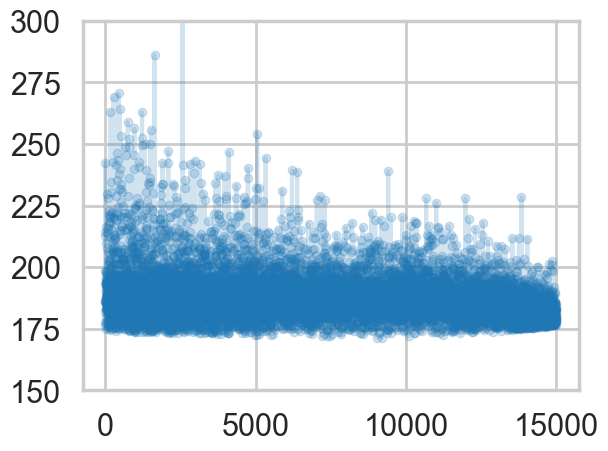

In [18]:
plt.plot(approx1.hist, '.-', alpha=0.2)
plt.ylim(150, 300)

In [19]:
samps1 = approx1.sample(10000)

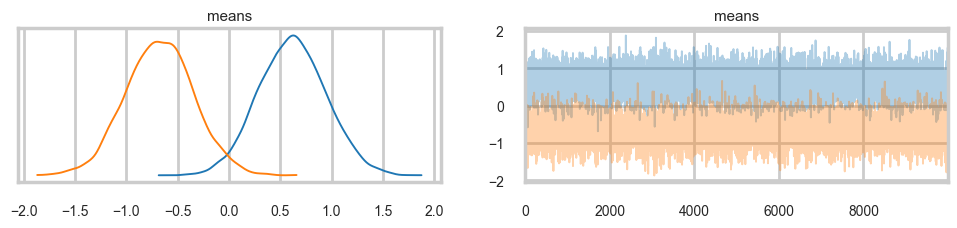

In [20]:
az.plot_trace(samps1);

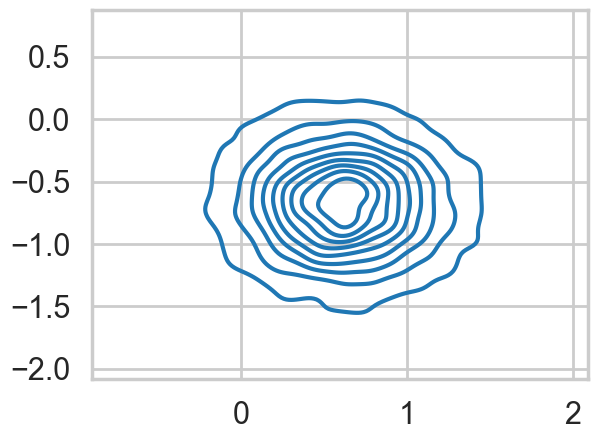

In [21]:
m = samps1.posterior['means'].values.reshape(-1, 2)
sns.kdeplot(x=m[:,0], y=m[:,1]);

In [22]:
with model2:
    approx2 = pm.fit(n=15000, method="advi")

/Users/rahul/Library/Caches/uv/archive-v0/WJgPh5nRFVZl0DU9tt8M7/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 178.72


(150.0, 300.0)

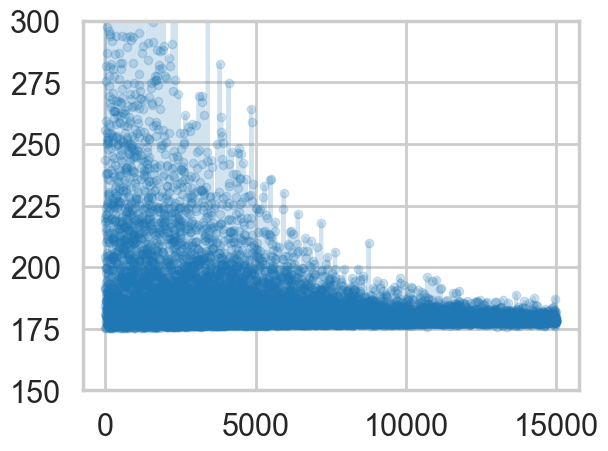

In [23]:
plt.plot(approx2.hist, '.-', alpha=0.2)
plt.ylim(150, 300)

In [24]:
samps2 = approx2.sample(10000)

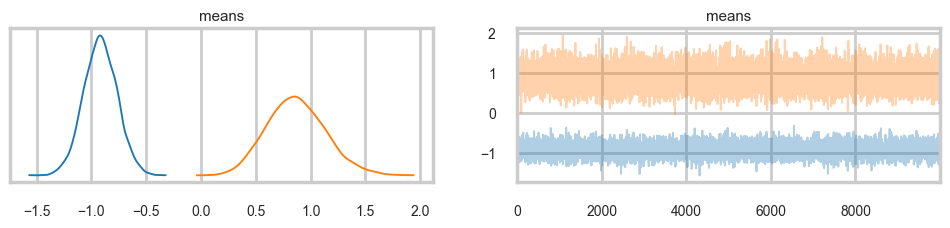

In [25]:
az.plot_trace(samps2);

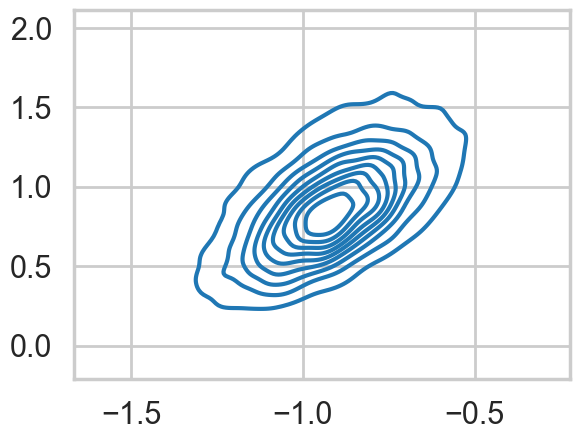

In [26]:
m = samps2.posterior['means'].values.reshape(-1, 2)
sns.kdeplot(x=m[:,0], y=m[:,1]);